In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
data_file = Path(
    "feature_engineered_manufacturing_dataset.csv"
)

print("Notebook location:", Path.cwd())
print("File exists:", data_file.exists())

if not data_file.exists():
    print("CSV files available:")
    
    for csv_file in Path(".").glob("*.csv"):
        print("-", csv_file.name)
else:
    feature_data = pd.read_csv(data_file)

    print("Dataset loaded successfully.")
    print("Dataset shape:", feature_data.shape)

Notebook location: c:\Users\User\AMDARI Project 1
File exists: True
Dataset loaded successfully.
Dataset shape: (10117, 67)


In [4]:
feature_data.head()

,shift_id,shift_name,start_time,end_time,supervisor_id,production_id,date,units_produced,defect_count,cycle_time_avg,shift_efficiency_score,operator_id,operator_name,experience_level,skill_category,machine_id,runtime_hours,downtime_minutes,maintenance_flag,machine_status,maintenance_id,issue_type,maintenance_downtime,resolved_by,qc_id,defect_type,severity,inspection_result,temperature,humidity,timestamp,start_datetime,end_datetime,temperature_was_missing,humidity_was_missing,timestamp_was_missing,efficiency_above_100_flag,invalid_production_flag,invalid_runtime_flag,invalid_downtime_flag,invalid_humidity_flag,day_of_week,day_number,is_weekend,month,shift_start_hour,shift_duration_hours,good_units,defect_rate_pct,quality_rate_pct,production_rate_per_hour,good_units_per_hour,runtime_minutes,available_minutes,machine_utilization_pct,downtime_percentage,availability_pct,total_stoppage_minutes,estimated_oee_pct,temperature_deviation,humidity_deviation,machine_issue_flag,experienced_operator_flag,experience_runtime_interaction,machine_prior_avg_units,machine_prior_avg_downtime,machine_prior_avg_defect_rate
0,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01 00:00:00,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,No maintenance,0.0,Not applicable,1,Material,Minor,Rework,22.3,49.9,2024-01-01 08:00:00,2024-01-01 06:00:00,2024-01-01 14:00:00,0,0,0,0,0,0,0,0,Monday,0,0,1,6,8.0,909,2.152853,97.847147,128.314917,125.552486,434.4,464.61,90.5,3.20625,96.79375,15.39,85.712481,2.6,4.8,0,1,50.68,661.304846,35.420947,3.470758
1,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01 00:00:00,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,No maintenance,0.0,Not applicable,2,Assembly,Minor,Accepted,22.3,49.9,2024-01-01 08:00:00,2024-01-01 06:00:00,2024-01-01 14:00:00,0,0,0,0,0,0,0,0,Monday,0,0,1,6,8.0,909,2.152853,97.847147,128.314917,125.552486,434.4,464.61,90.5,3.20625,96.79375,15.39,85.712481,2.6,4.8,0,1,50.68,661.304846,35.420947,3.470758
2,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01 00:00:00,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,No maintenance,0.0,Not applicable,3,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00,2024-01-01 06:00:00,2024-01-01 14:00:00,0,0,0,0,0,0,0,0,Monday,0,0,1,6,8.0,909,2.152853,97.847147,128.314917,125.552486,434.4,464.61,90.5,3.20625,96.79375,15.39,85.712481,2.6,4.8,0,1,50.68,661.304846,35.420947,3.470758
3,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01 00:00:00,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,No maintenance,0.0,Not applicable,4,Dimensional,Minor,Rework,22.3,49.9,2024-01-01 08:00:00,2024-01-01 06:00:00,2024-01-01 14:00:00,0,0,0,0,0,0,0,0,Monday,0,0,1,6,8.0,909,2.152853,97.847147,128.314917,125.552486,434.4,464.61,90.5,3.20625,96.79375,15.39,85.712481,2.6,4.8,0,1,50.68,661.304846,35.420947,3.470758
4,1,Morning,06:00:00.0000000,14:00:00.0000000,SUP_01,1,2024-01-01 00:00:00,929,20,35.65,95.945255,OP_019,Operator_19,7,Expert,MC_001,7.24,15.39,0,Operational,NaN,No maintenance,0.0,Not applicable,5,Cosmetic,Minor,Rework,22.3,49.9,2024-01-01 08:00:00,2024-01-01 06:00:00,2024-01-01 14:00:00,0,0,0,0,0,0,0,0,Monday,0,0,1,6,8.0,909,2.152853,97.847147,128.314917,125.552486,434.4,464.61,90.5,3.20625,96.79375,15.39,85.712481,2.6,4.8,0,1,50.68,661.304846,35.420947,3.470758


In [5]:
target = "shift_efficiency_score"

print("Target exists:", target in feature_data.columns)
print("Target data type:", feature_data[target].dtype)
print("Missing target values:", feature_data[target].isna().sum())

feature_data[target].describe().round(2)

Target exists: True
Target data type: float64
Missing target values: 0


count    10117.00
mean        79.04
std         12.84
min         49.61
25%         68.09
50%         80.00
75%         91.92
max        103.68
Name: shift_efficiency_score, dtype: float64

In [6]:
excluded_features = {
    "shift_id": "Database identifier",
    "supervisor_id": "Administrative identifier",
    "production_id": "Production-record identifier",
    "operator_id": "Operator identifier",
    "operator_name": "Operator name; duplicates operator identity",
    "maintenance_id": "Maintenance-record identifier",
    "qc_id": "Quality-control identifier",
    "date": "Raw date replaced by engineered time features",
    "start_time": "Raw time replaced by datetime features",
    "end_time": "Raw time replaced by datetime features",
    "start_datetime": "Raw datetime replaced by extracted features",
    "end_datetime": "Raw datetime replaced by extracted features",
    "timestamp": "Raw timestamp",
    "efficiency_above_100_flag":
        "Directly calculated from the target; causes target leakage",
    "invalid_production_flag":
        "Data-cleaning validation flag",
    "invalid_runtime_flag":
        "Data-cleaning validation flag",
    "invalid_downtime_flag":
        "Data-cleaning validation flag",
    "invalid_humidity_flag":
        "Data-cleaning validation flag"
}

exclusion_report = pd.DataFrame(
    excluded_features.items(),
    columns=["Excluded variable", "Reason for exclusion"]
)

exclusion_report

,Excluded variable,Reason for exclusion
0,shift_id,Database identifier
1,supervisor_id,Administrative identifier
2,production_id,Production-record identifier
3,operator_id,Operator identifier
4,operator_name,Operator name; duplicates operator identity
5,maintenance_id,Maintenance-record identifier
6,qc_id,Quality-control identifier
7,date,Raw date replaced by engineered time features
8,start_time,Raw time replaced by datetime features
9,end_time,Raw time replaced by datetime features


In [7]:
numeric_candidates = [
    "units_produced",
    "defect_count",
    "cycle_time_avg",
    "experience_level",
    "runtime_hours",
    "downtime_minutes",
    "maintenance_flag",
    "maintenance_downtime",
    "temperature",
    "humidity",
    "good_units",
    "defect_rate_pct",
    "production_rate_per_hour",
    "estimated_oee_pct",
    "temperature_deviation",
    "humidity_deviation",
    "experience_runtime_interaction",
    "shift_start_hour",
    "shift_duration_hours",
    "machine_prior_avg_units",
    "machine_prior_avg_downtime",
    "machine_prior_avg_defect_rate"
]

categorical_candidates = [
    "shift_name",
    "skill_category",
    "machine_id",
    "machine_status",
    "issue_type",
    "defect_type",
    "severity",
    "inspection_result",
    "day_of_week"
]

numeric_candidates = [
    column for column in numeric_candidates
    if column in feature_data.columns
]

categorical_candidates = [
    column for column in categorical_candidates
    if column in feature_data.columns
]

candidate_features = (
    numeric_candidates
    + categorical_candidates
)

X = feature_data[candidate_features].copy()
y = feature_data[target].copy()

candidate_summary = pd.DataFrame({
    "Measure": [
        "Dataset rows",
        "Candidate numerical variables",
        "Candidate categorical variables",
        "Total candidate variables",
        "Target variable"
    ],
    "Result": [
        len(X),
        len(numeric_candidates),
        len(categorical_candidates),
        len(candidate_features),
        target
    ]
})

candidate_summary

,Measure,Result
0,Dataset rows,10117
1,Candidate numerical variables,22
2,Candidate categorical variables,9
3,Total candidate variables,31
4,Target variable,shift_efficiency_score


In [8]:
correlation_with_target = (
    feature_data[
        numeric_candidates + [target]
    ]
    .corr(numeric_only=True)[target]
    .drop(target)
    .sort_values(
        key=abs,
        ascending=False
    )
    .rename("correlation")
    .to_frame()
)

correlation_with_target[
    "absolute_correlation"
] = (
    correlation_with_target["correlation"].abs()
)

correlation_with_target.round(3)

,correlation,absolute_correlation
shift_start_hour,-0.945,0.945
units_produced,0.927,0.927
good_units,0.927,0.927
estimated_oee_pct,0.927,0.927
production_rate_per_hour,0.922,0.922
runtime_hours,0.916,0.916
downtime_minutes,-0.916,0.916
defect_rate_pct,-0.880,0.880
experience_runtime_interaction,0.731,0.731
experience_level,0.715,0.715


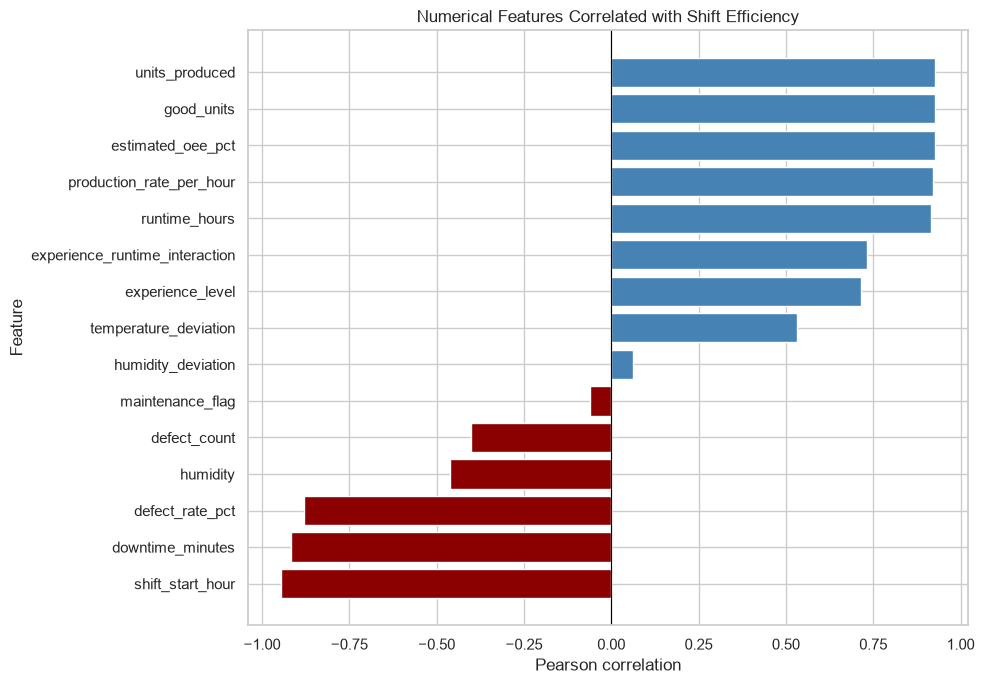

In [9]:
top_correlations = (
    correlation_with_target
    .head(15)
    .sort_values("correlation")
)

plt.figure(figsize=(10, 7))

colours = [
    "darkred" if value < 0 else "steelblue"
    for value in top_correlations["correlation"]
]

plt.barh(
    top_correlations.index,
    top_correlations["correlation"],
    color=colours
)

plt.axvline(
    0,
    color="black",
    linewidth=0.8
)

plt.title(
    "Numerical Features Correlated with Shift Efficiency"
)
plt.xlabel("Pearson correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [10]:
predictor_correlation = (
    feature_data[numeric_candidates]
    .corr()
    .abs()
)

upper_triangle = predictor_correlation.where(
    np.triu(
        np.ones(predictor_correlation.shape),
        k=1
    ).astype(bool)
)

high_correlation_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

high_correlation_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Absolute correlation"
]

high_correlation_pairs = (
    high_correlation_pairs[
        high_correlation_pairs[
            "Absolute correlation"
        ] >= 0.90
    ]
    .sort_values(
        "Absolute correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

high_correlation_pairs.round(3)

,Feature 1,Feature 2,Absolute correlation
0,runtime_hours,downtime_minutes,1.000
1,units_produced,good_units,1.000
2,experience_level,experience_runtime_interaction,0.999
3,units_produced,production_rate_per_hour,0.998
4,good_units,production_rate_per_hour,0.998
5,downtime_minutes,estimated_oee_pct,0.997
6,runtime_hours,estimated_oee_pct,0.997
7,estimated_oee_pct,shift_start_hour,0.959
8,units_produced,shift_start_hour,0.954
9,good_units,shift_start_hour,0.954


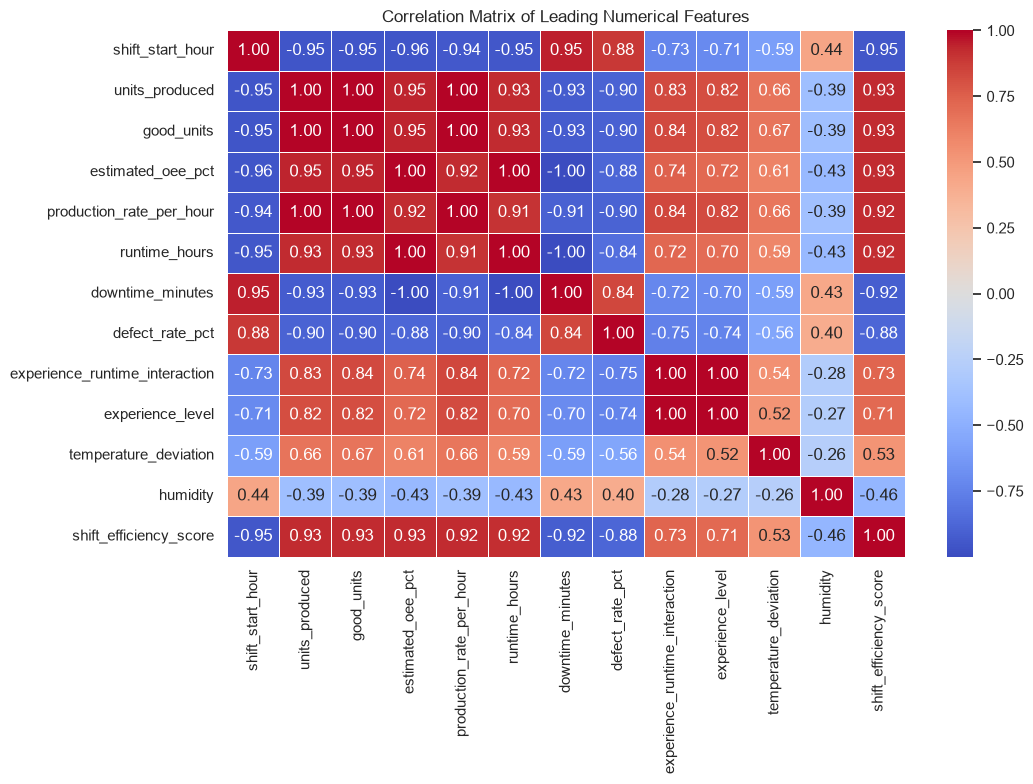

In [11]:
heatmap_features = (
    correlation_with_target
    .head(12)
    .index
    .tolist()
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    feature_data[
        heatmap_features + [target]
    ].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Leading Numerical Features"
)
plt.tight_layout()
plt.show()

In [12]:
from sklearn.linear_model import LinearRegression

def calculate_vif(dataframe):
    clean_data = dataframe.copy()

    clean_data = clean_data.replace(
        [np.inf, -np.inf],
        np.nan
    )

    clean_data = clean_data.fillna(
        clean_data.median()
    )

    clean_data = clean_data.loc[
        :,
        clean_data.nunique() > 1
    ]

    vif_results = []

    for column in clean_data.columns:
        other_columns = [
            item for item in clean_data.columns
            if item != column
        ]

        model = LinearRegression()

        model.fit(
            clean_data[other_columns],
            clean_data[column]
        )

        r_squared = model.score(
            clean_data[other_columns],
            clean_data[column]
        )

        if r_squared >= 0.999999:
            vif = np.inf
        else:
            vif = 1 / (1 - r_squared)

        vif_results.append({
            "Feature": column,
            "VIF": vif
        })

    return (
        pd.DataFrame(vif_results)
        .sort_values(
            "VIF",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [13]:
vif_report = calculate_vif(
    feature_data[numeric_candidates]
)

vif_report.round(2)

,Feature,VIF
0,units_produced,inf
1,defect_count,inf
2,good_units,inf
3,production_rate_per_hour,16007.74
4,estimated_oee_pct,14565.57
5,downtime_minutes,12199.21
6,runtime_hours,9372.41
7,experience_runtime_interaction,2528.62
8,experience_level,2315.83
9,defect_rate_pct,341.05


In [14]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )
)

split_summary = pd.DataFrame({
    "Dataset": [
        "Training predictors",
        "Testing predictors",
        "Training target",
        "Testing target"
    ],
    "Rows": [
        X_train.shape[0],
        X_test.shape[0],
        y_train.shape[0],
        y_test.shape[0]
    ]
})

split_summary

,Dataset,Rows
0,Training predictors,8093
1,Testing predictors,2024
2,Training target,8093
3,Testing target,2024


In [15]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numeric_transformer,
            numeric_candidates
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_candidates
        )
    ],
    verbose_feature_names_out=False
)

X_train_processed = (
    preprocessor.fit_transform(X_train)
)

X_test_processed = (
    preprocessor.transform(X_test)
)

encoded_feature_names = (
    preprocessor.get_feature_names_out()
)

print(
    "Training data before encoding:",
    X_train.shape
)

print(
    "Training data after encoding:",
    X_train_processed.shape
)

print(
    "Encoded features:",
    len(encoded_feature_names)
)

Training data before encoding: (8093, 31)
Training data after encoding: (8093, 101)
Encoded features: 101


In [16]:
importance_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

importance_model.fit(
    X_train_processed,
    y_train
)

test_predictions = importance_model.predict(
    X_test_processed
)

model_check = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R-squared"
    ],
    "Result": [
        mean_absolute_error(
            y_test,
            test_predictions
        ),
        np.sqrt(
            mean_squared_error(
                y_test,
                test_predictions
            )
        ),
        r2_score(
            y_test,
            test_predictions
        )
    ]
})

model_check.round(4)

,Metric,Result
0,MAE,0.2034
1,RMSE,0.3827
2,R-squared,0.9991


In [17]:
encoded_importance = (
    pd.DataFrame({
        "Encoded feature":
            encoded_feature_names,

        "Random Forest importance":
            importance_model.feature_importances_
    })
    .sort_values(
        "Random Forest importance",
        ascending=False
    )
    .reset_index(drop=True)
)

encoded_importance.head(20).round(4)

,Encoded feature,Random Forest importance
0,production_rate_per_hour,0.7412
1,good_units,0.0692
2,shift_name_Morning,0.0664
3,shift_name_Evening,0.0326
4,units_produced,0.0229
5,estimated_oee_pct,0.0189
6,shift_start_hour,0.0104
7,cycle_time_avg,0.0048
8,machine_prior_avg_downtime,0.0037
9,experience_runtime_interaction,0.0036


In [18]:
def identify_source_feature(encoded_name):
    for column in sorted(
        categorical_candidates,
        key=len,
        reverse=True
    ):
        if encoded_name.startswith(
            column + "_"
        ):
            return column

    return encoded_name


encoded_importance["Original feature"] = (
    encoded_importance[
        "Encoded feature"
    ].apply(identify_source_feature)
)

random_forest_importance = (
    encoded_importance
    .groupby(
        "Original feature",
        as_index=False
    )["Random Forest importance"]
    .sum()
    .sort_values(
        "Random Forest importance",
        ascending=False
    )
    .reset_index(drop=True)
)

random_forest_importance.head(20).round(4)

,Original feature,Random Forest importance
0,production_rate_per_hour,0.7412
1,shift_name,0.0990
2,good_units,0.0692
3,units_produced,0.0229
4,estimated_oee_pct,0.0189
5,shift_start_hour,0.0104
6,machine_id,0.0090
7,cycle_time_avg,0.0048
8,machine_prior_avg_downtime,0.0037
9,experience_runtime_interaction,0.0036


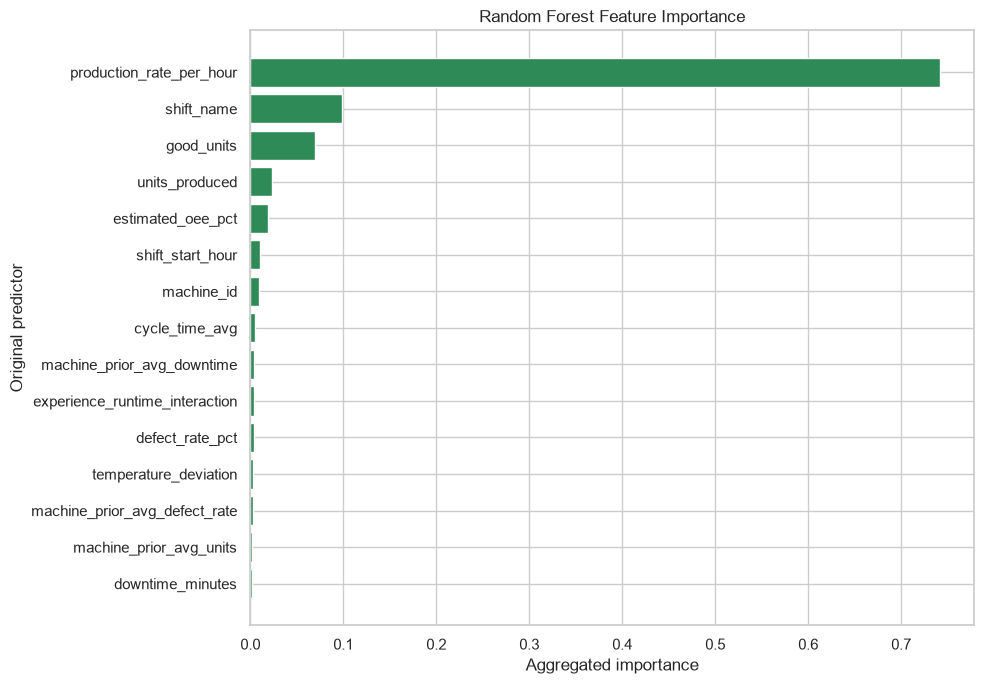

In [19]:
top_rf_features = (
    random_forest_importance
    .head(15)
    .sort_values(
        "Random Forest importance"
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_rf_features["Original feature"],
    top_rf_features[
        "Random Forest importance"
    ],
    color="seagreen"
)

plt.title(
    "Random Forest Feature Importance"
)
plt.xlabel("Aggregated importance")
plt.ylabel("Original predictor")
plt.tight_layout()
plt.show()

In [20]:
rfe_estimator = RandomForestRegressor(
    n_estimators=80,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rfe_selector = RFE(
    estimator=rfe_estimator,
    n_features_to_select=20,
    step=0.20
)

rfe_selector.fit(
    X_train_processed,
    y_train
)

rfe_encoded_results = pd.DataFrame({
    "Encoded feature":
        encoded_feature_names,

    "RFE selected":
        rfe_selector.support_,

    "RFE ranking":
        rfe_selector.ranking_
})

rfe_encoded_results = (
    rfe_encoded_results
    .sort_values(
        [
            "RFE selected",
            "RFE ranking"
        ],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

rfe_encoded_results.head(30)

,Encoded feature,RFE selected,RFE ranking
0,units_produced,True,1
1,defect_count,True,1
2,cycle_time_avg,True,1
3,runtime_hours,True,1
4,downtime_minutes,True,1
5,maintenance_downtime,True,1
6,good_units,True,1
7,defect_rate_pct,True,1
8,production_rate_per_hour,True,1
9,estimated_oee_pct,True,1


In [21]:
rfe_encoded_results["Original feature"] = (
    rfe_encoded_results[
        "Encoded feature"
    ].apply(identify_source_feature)
)

rfe_original_results = (
    rfe_encoded_results
    .groupby(
        "Original feature",
        as_index=False
    )
    .agg(
        rfe_selected=(
            "RFE selected",
            "max"
        ),
        best_rfe_ranking=(
            "RFE ranking",
            "min"
        )
    )
    .sort_values(
        [
            "rfe_selected",
            "best_rfe_ranking"
        ],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

rfe_original_results.head(30)

,Original feature,rfe_selected,best_rfe_ranking
0,cycle_time_avg,True,1
1,defect_count,True,1
2,defect_rate_pct,True,1
3,downtime_minutes,True,1
4,estimated_oee_pct,True,1
5,experience_runtime_interaction,True,1
6,good_units,True,1
7,machine_id,True,1
8,machine_prior_avg_defect_rate,True,1
9,machine_prior_avg_downtime,True,1


In [22]:
comparison = pd.DataFrame({
    "Feature": candidate_features
})

comparison = comparison.merge(
    correlation_with_target[
        ["absolute_correlation"]
    ],
    left_on="Feature",
    right_index=True,
    how="left"
)

comparison = comparison.merge(
    random_forest_importance,
    left_on="Feature",
    right_on="Original feature",
    how="left"
)

comparison = comparison.merge(
    rfe_original_results,
    left_on="Feature",
    right_on="Original feature",
    how="left",
    suffixes=("", "_rfe")
)

comparison = comparison.drop(
    columns=[
        "Original feature",
        "Original feature_rfe"
    ],
    errors="ignore"
)

comparison[
    "absolute_correlation"
] = comparison[
    "absolute_correlation"
].fillna(0)

comparison[
    "Random Forest importance"
] = comparison[
    "Random Forest importance"
].fillna(0)

comparison[
    "rfe_selected"
] = comparison[
    "rfe_selected"
].fillna(False).astype(int)

maximum_correlation = comparison[
    "absolute_correlation"
].max()

maximum_importance = comparison[
    "Random Forest importance"
].max()

comparison[
    "correlation_score"
] = (
    comparison["absolute_correlation"]
    / maximum_correlation
)

comparison[
    "importance_score"
] = (
    comparison["Random Forest importance"]
    / maximum_importance
)

comparison["combined_score"] = (
    comparison["correlation_score"] * 0.30
    + comparison["importance_score"] * 0.50
    + comparison["rfe_selected"] * 0.20
)

comparison = (
    comparison
    .sort_values(
        "combined_score",
        ascending=False
    )
    .reset_index(drop=True)
)

comparison[
    [
        "Feature",
        "absolute_correlation",
        "Random Forest importance",
        "rfe_selected",
        "combined_score"
    ]
].head(25).round(4)

,Feature,absolute_correlation,Random Forest importance,rfe_selected,combined_score
0,production_rate_per_hour,0.9220,0.7412,1,0.9926
1,good_units,0.9269,0.0692,1,0.5408
2,units_produced,0.9272,0.0229,1,0.5097
3,shift_start_hour,0.9454,0.0104,1,0.5070
4,estimated_oee_pct,0.9267,0.0189,1,0.5068
5,downtime_minutes,0.9163,0.0020,1,0.4921
6,runtime_hours,0.9164,0.0007,1,0.4913
7,defect_rate_pct,0.8796,0.0034,1,0.4814
8,experience_runtime_interaction,0.7311,0.0036,1,0.4344
9,temperature_deviation,0.5311,0.0026,1,0.3703


In [23]:
redundant_or_leakage_features = {
    "efficiency_above_100_flag",
    "runtime_minutes",
    "available_minutes",
    "machine_utilization_pct",
    "downtime_percentage",
    "availability_pct",
    "quality_rate_pct",
    "good_units_per_hour"
}

ranked_eligible_features = [
    feature
    for feature in comparison["Feature"]
    if feature not in redundant_or_leakage_features
]

final_features = ranked_eligible_features[:20]

final_feature_set = (
    comparison[
        comparison["Feature"].isin(
            final_features
        )
    ]
    .copy()
)

final_feature_set[
    "Final selection"
] = "Selected"

final_feature_set = (
    final_feature_set
    .sort_values(
        "combined_score",
        ascending=False
    )
    .reset_index(drop=True)
)

final_feature_set[
    [
        "Feature",
        "absolute_correlation",
        "Random Forest importance",
        "rfe_selected",
        "combined_score",
        "Final selection"
    ]
].round(4)

,Feature,absolute_correlation,Random Forest importance,rfe_selected,combined_score,Final selection
0,production_rate_per_hour,0.9220,0.7412,1,0.9926,Selected
1,good_units,0.9269,0.0692,1,0.5408,Selected
2,units_produced,0.9272,0.0229,1,0.5097,Selected
3,shift_start_hour,0.9454,0.0104,1,0.5070,Selected
4,estimated_oee_pct,0.9267,0.0189,1,0.5068,Selected
5,downtime_minutes,0.9163,0.0020,1,0.4921,Selected
6,runtime_hours,0.9164,0.0007,1,0.4913,Selected
7,defect_rate_pct,0.8796,0.0034,1,0.4814,Selected
8,experience_runtime_interaction,0.7311,0.0036,1,0.4344,Selected
9,temperature_deviation,0.5311,0.0026,1,0.3703,Selected


In [24]:
print("FINAL MODELLING FEATURES")
print("=" * 50)

for number, feature in enumerate(
    final_features,
    start=1
):
    print(f"{number}. {feature}")

print("\nNumber of selected features:", len(final_features))

FINAL MODELLING FEATURES
1. production_rate_per_hour
2. good_units
3. units_produced
4. shift_start_hour
5. estimated_oee_pct
6. downtime_minutes
7. runtime_hours
8. defect_rate_pct
9. experience_runtime_interaction
10. temperature_deviation
11. defect_count
12. shift_name
13. experience_level
14. cycle_time_avg
15. machine_prior_avg_downtime
16. machine_prior_avg_defect_rate
17. machine_id
18. machine_prior_avg_units
19. maintenance_downtime
20. humidity

Number of selected features: 20


In [25]:
final_model_data = feature_data[
    final_features + [target]
].copy()

final_dataset_summary = pd.DataFrame({
    "Measure": [
        "Rows",
        "Selected predictors",
        "Target variables",
        "Total columns",
        "Missing values",
        "Duplicate rows"
    ],
    "Result": [
        final_model_data.shape[0],
        len(final_features),
        1,
        final_model_data.shape[1],
        final_model_data.isna().sum().sum(),
        final_model_data.duplicated().sum()
    ]
})

final_dataset_summary

,Measure,Result
0,Rows,10117
1,Selected predictors,20
2,Target variables,1
3,Total columns,21
4,Missing values,0
5,Duplicate rows,9634


In [26]:
final_feature_file = Path(
    "final_feature_set.csv"
)

final_dataset_file = Path(
    "final_modeling_dataset.csv"
)

comparison_file = Path(
    "feature_selection_comparison.csv"
)

final_feature_set.to_csv(
    final_feature_file,
    index=False
)

final_model_data.to_csv(
    final_dataset_file,
    index=False
)

comparison.to_csv(
    comparison_file,
    index=False
)

print("Files exported successfully.")
print(
    "Final feature set:",
    final_feature_file
)
print(
    "Final modelling dataset:",
    final_dataset_file
)
print(
    "Method comparison:",
    comparison_file
)

print(
    "\nFinal modelling shape:",
    final_model_data.shape
)

print(
    "Feature-set file exists:",
    final_feature_file.exists()
)

print(
    "Modelling dataset exists:",
    final_dataset_file.exists()
)

Files exported successfully.
Final feature set: final_feature_set.csv
Final modelling dataset: final_modeling_dataset.csv
Method comparison: feature_selection_comparison.csv

Final modelling shape: (10117, 21)
Feature-set file exists: True
Modelling dataset exists: True


In [27]:
print("Dataset shape:", feature_data.shape)
print("Target exists:", target in feature_data.columns)
print("Target data type:", feature_data[target].dtype)
print(
    "Missing target values:",
    feature_data[target].isna().sum()
)

feature_data[target].describe().round(2)

Dataset shape: (10117, 67)
Target exists: True
Target data type: float64
Missing target values: 0


count    10117.00
mean        79.04
std         12.84
min         49.61
25%         68.09
50%         80.00
75%         91.92
max        103.68
Name: shift_efficiency_score, dtype: float64

In [28]:
candidate_summary   

,Measure,Result
0,Dataset rows,10117
1,Candidate numerical variables,22
2,Candidate categorical variables,9
3,Total candidate variables,31
4,Target variable,shift_efficiency_score


In [29]:
exclusion_report

,Excluded variable,Reason for exclusion
0,shift_id,Database identifier
1,supervisor_id,Administrative identifier
2,production_id,Production-record identifier
3,operator_id,Operator identifier
4,operator_name,Operator name; duplicates operator identity
5,maintenance_id,Maintenance-record identifier
6,qc_id,Quality-control identifier
7,date,Raw date replaced by engineered time features
8,start_time,Raw time replaced by datetime features
9,end_time,Raw time replaced by datetime features


In [30]:
correlation_with_target.head(15).round(3)

,correlation,absolute_correlation
shift_start_hour,-0.945,0.945
units_produced,0.927,0.927
good_units,0.927,0.927
estimated_oee_pct,0.927,0.927
production_rate_per_hour,0.922,0.922
runtime_hours,0.916,0.916
downtime_minutes,-0.916,0.916
defect_rate_pct,-0.880,0.880
experience_runtime_interaction,0.731,0.731
experience_level,0.715,0.715


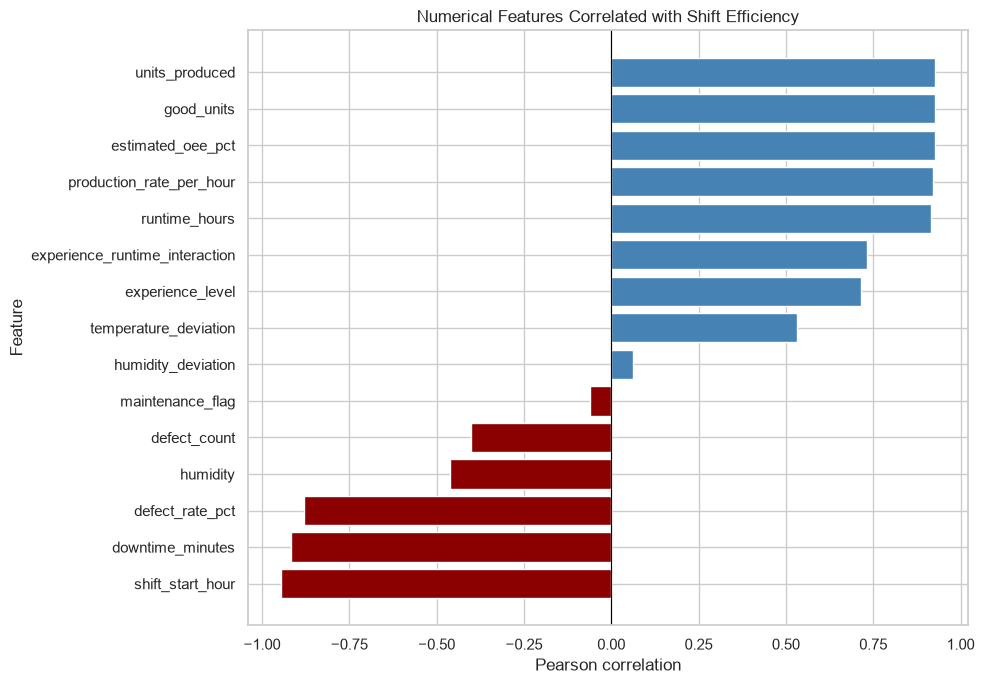

In [31]:
top_correlations = (
    correlation_with_target
    .head(15)
    .sort_values("correlation")
)

plt.figure(figsize=(10, 7))

colours = [
    "darkred" if value < 0 else "steelblue"
    for value in top_correlations["correlation"]
]

plt.barh(
    top_correlations.index,
    top_correlations["correlation"],
    color=colours
)

plt.axvline(0, color="black", linewidth=0.8)
plt.title(
    "Numerical Features Correlated with Shift Efficiency"
)
plt.xlabel("Pearson correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [32]:
high_correlation_pairs.round(3)

,Feature 1,Feature 2,Absolute correlation
0,runtime_hours,downtime_minutes,1.000
1,units_produced,good_units,1.000
2,experience_level,experience_runtime_interaction,0.999
3,units_produced,production_rate_per_hour,0.998
4,good_units,production_rate_per_hour,0.998
5,downtime_minutes,estimated_oee_pct,0.997
6,runtime_hours,estimated_oee_pct,0.997
7,estimated_oee_pct,shift_start_hour,0.959
8,units_produced,shift_start_hour,0.954
9,good_units,shift_start_hour,0.954


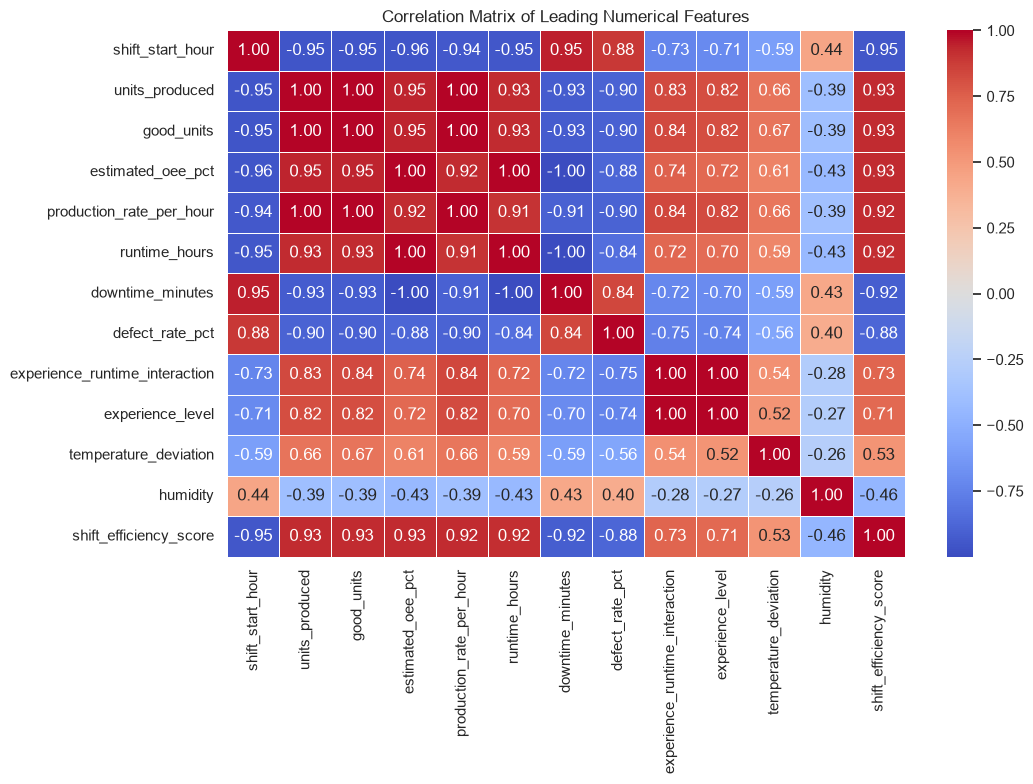

In [33]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    feature_data[
        heatmap_features + [target]
    ].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Leading Numerical Features"
)
plt.tight_layout()
plt.show()

In [34]:
print("Dataset shape:", feature_data.shape)
print("Target exists:", target in feature_data.columns)
print("Target data type:", feature_data[target].dtype)
print(
    "Missing target values:",
    feature_data[target].isna().sum()
)

feature_data[target].describe().round(2)

Dataset shape: (10117, 67)
Target exists: True
Target data type: float64
Missing target values: 0


count    10117.00
mean        79.04
std         12.84
min         49.61
25%         68.09
50%         80.00
75%         91.92
max        103.68
Name: shift_efficiency_score, dtype: float64

In [35]:
candidate_summary

,Measure,Result
0,Dataset rows,10117
1,Candidate numerical variables,22
2,Candidate categorical variables,9
3,Total candidate variables,31
4,Target variable,shift_efficiency_score


In [36]:
exclusion_report

,Excluded variable,Reason for exclusion
0,shift_id,Database identifier
1,supervisor_id,Administrative identifier
2,production_id,Production-record identifier
3,operator_id,Operator identifier
4,operator_name,Operator name; duplicates operator identity
5,maintenance_id,Maintenance-record identifier
6,qc_id,Quality-control identifier
7,date,Raw date replaced by engineered time features
8,start_time,Raw time replaced by datetime features
9,end_time,Raw time replaced by datetime features


In [37]:
correlation_with_target.head(15).round(3)

,correlation,absolute_correlation
shift_start_hour,-0.945,0.945
units_produced,0.927,0.927
good_units,0.927,0.927
estimated_oee_pct,0.927,0.927
production_rate_per_hour,0.922,0.922
runtime_hours,0.916,0.916
downtime_minutes,-0.916,0.916
defect_rate_pct,-0.880,0.880
experience_runtime_interaction,0.731,0.731
experience_level,0.715,0.715


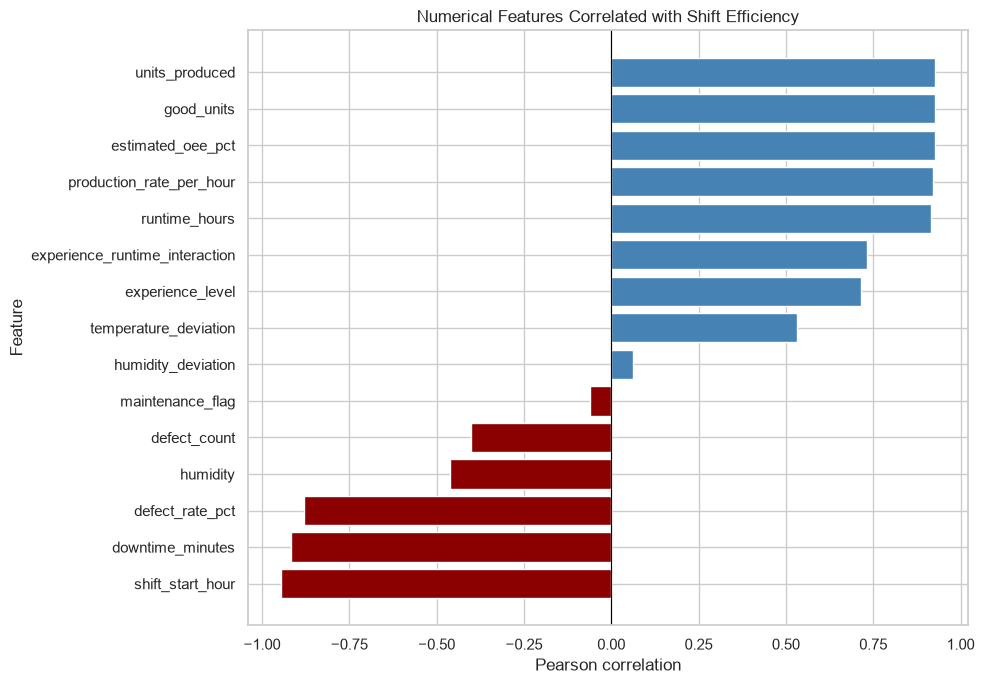

In [38]:
top_correlations = (
    correlation_with_target
    .head(15)
    .sort_values("correlation")
)

plt.figure(figsize=(10, 7))

colours = [
    "darkred" if value < 0 else "steelblue"
    for value in top_correlations["correlation"]
]

plt.barh(
    top_correlations.index,
    top_correlations["correlation"],
    color=colours
)

plt.axvline(0, color="black", linewidth=0.8)
plt.title(
    "Numerical Features Correlated with Shift Efficiency"
)
plt.xlabel("Pearson correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [39]:
high_correlation_pairs.round(3)

,Feature 1,Feature 2,Absolute correlation
0,runtime_hours,downtime_minutes,1.000
1,units_produced,good_units,1.000
2,experience_level,experience_runtime_interaction,0.999
3,units_produced,production_rate_per_hour,0.998
4,good_units,production_rate_per_hour,0.998
5,downtime_minutes,estimated_oee_pct,0.997
6,runtime_hours,estimated_oee_pct,0.997
7,estimated_oee_pct,shift_start_hour,0.959
8,units_produced,shift_start_hour,0.954
9,good_units,shift_start_hour,0.954


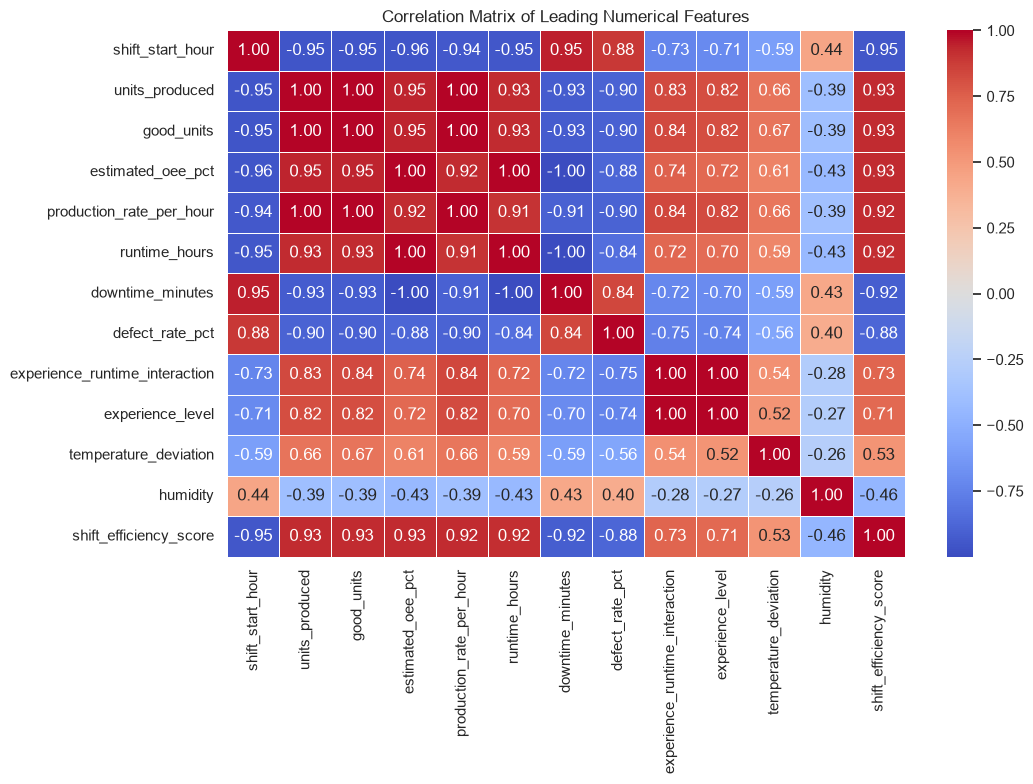

In [40]:
plt.figure(figsize=(11, 8))

sns.heatmap(
    feature_data[
        heatmap_features + [target]
    ].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Leading Numerical Features"
)
plt.tight_layout()
plt.show()

In [41]:
vif_report.head(15).round(2)

,Feature,VIF
0,units_produced,inf
1,defect_count,inf
2,good_units,inf
3,production_rate_per_hour,16007.74
4,estimated_oee_pct,14565.57
5,downtime_minutes,12199.21
6,runtime_hours,9372.41
7,experience_runtime_interaction,2528.62
8,experience_level,2315.83
9,defect_rate_pct,341.05


In [42]:
split_summary

,Dataset,Rows
0,Training predictors,8093
1,Testing predictors,2024
2,Training target,8093
3,Testing target,2024


In [43]:
model_check.round(4)

,Metric,Result
0,MAE,0.2034
1,RMSE,0.3827
2,R-squared,0.9991


In [44]:
random_forest_importance.head(20).round(4)

,Original feature,Random Forest importance
0,production_rate_per_hour,0.7412
1,shift_name,0.0990
2,good_units,0.0692
3,units_produced,0.0229
4,estimated_oee_pct,0.0189
5,shift_start_hour,0.0104
6,machine_id,0.0090
7,cycle_time_avg,0.0048
8,machine_prior_avg_downtime,0.0037
9,experience_runtime_interaction,0.0036


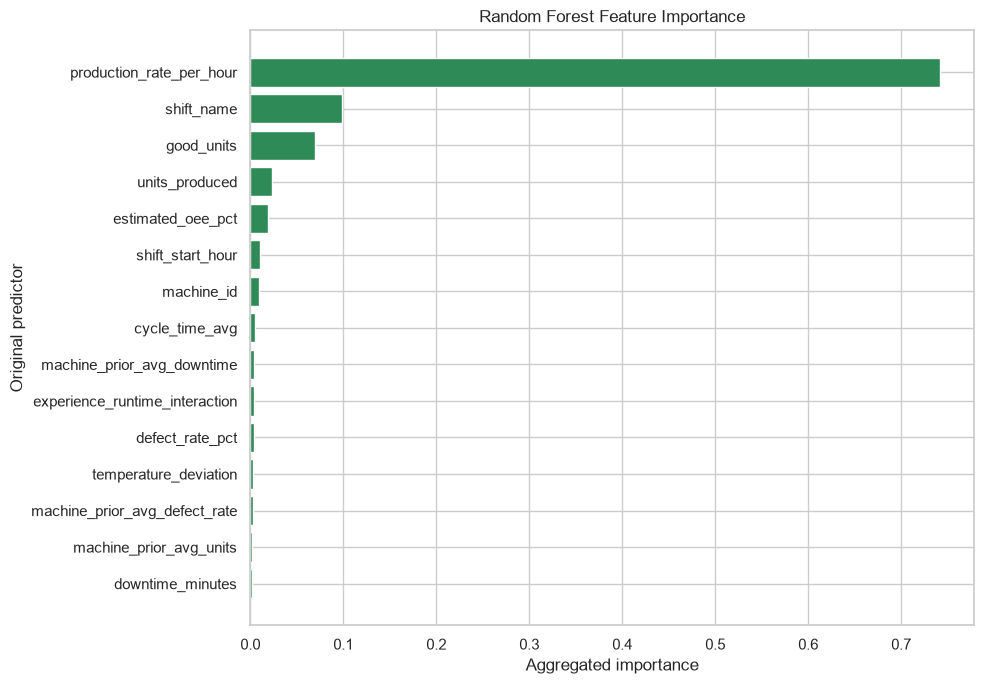

In [45]:
top_rf_features = (
    random_forest_importance
    .head(15)
    .sort_values("Random Forest importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_rf_features["Original feature"],
    top_rf_features["Random Forest importance"],
    color="seagreen"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Aggregated importance")
plt.ylabel("Original predictor")
plt.tight_layout()
plt.show()

In [46]:
rfe_original_results[
    rfe_original_results["rfe_selected"]
]

,Original feature,rfe_selected,best_rfe_ranking
0,cycle_time_avg,True,1
1,defect_count,True,1
2,defect_rate_pct,True,1
3,downtime_minutes,True,1
4,estimated_oee_pct,True,1
5,experience_runtime_interaction,True,1
6,good_units,True,1
7,machine_id,True,1
8,machine_prior_avg_defect_rate,True,1
9,machine_prior_avg_downtime,True,1


In [47]:
comparison[
    [
        "Feature",
        "absolute_correlation",
        "Random Forest importance",
        "rfe_selected",
        "combined_score"
    ]
].head(25).round(4)

,Feature,absolute_correlation,Random Forest importance,rfe_selected,combined_score
0,production_rate_per_hour,0.9220,0.7412,1,0.9926
1,good_units,0.9269,0.0692,1,0.5408
2,units_produced,0.9272,0.0229,1,0.5097
3,shift_start_hour,0.9454,0.0104,1,0.5070
4,estimated_oee_pct,0.9267,0.0189,1,0.5068
5,downtime_minutes,0.9163,0.0020,1,0.4921
6,runtime_hours,0.9164,0.0007,1,0.4913
7,defect_rate_pct,0.8796,0.0034,1,0.4814
8,experience_runtime_interaction,0.7311,0.0036,1,0.4344
9,temperature_deviation,0.5311,0.0026,1,0.3703


In [48]:
final_feature_set[
    [
        "Feature",
        "absolute_correlation",
        "Random Forest importance",
        "rfe_selected",
        "combined_score",
        "Final selection"
    ]
].round(4)

,Feature,absolute_correlation,Random Forest importance,rfe_selected,combined_score,Final selection
0,production_rate_per_hour,0.9220,0.7412,1,0.9926,Selected
1,good_units,0.9269,0.0692,1,0.5408,Selected
2,units_produced,0.9272,0.0229,1,0.5097,Selected
3,shift_start_hour,0.9454,0.0104,1,0.5070,Selected
4,estimated_oee_pct,0.9267,0.0189,1,0.5068,Selected
5,downtime_minutes,0.9163,0.0020,1,0.4921,Selected
6,runtime_hours,0.9164,0.0007,1,0.4913,Selected
7,defect_rate_pct,0.8796,0.0034,1,0.4814,Selected
8,experience_runtime_interaction,0.7311,0.0036,1,0.4344,Selected
9,temperature_deviation,0.5311,0.0026,1,0.3703,Selected


In [49]:
print("FINAL MODELLING FEATURES")
print("=" * 50)

for number, feature in enumerate(
    final_features,
    start=1
):
    print(f"{number}. {feature}")

print(
    "\nNumber of selected features:",
    len(final_features)
)

FINAL MODELLING FEATURES
1. production_rate_per_hour
2. good_units
3. units_produced
4. shift_start_hour
5. estimated_oee_pct
6. downtime_minutes
7. runtime_hours
8. defect_rate_pct
9. experience_runtime_interaction
10. temperature_deviation
11. defect_count
12. shift_name
13. experience_level
14. cycle_time_avg
15. machine_prior_avg_downtime
16. machine_prior_avg_defect_rate
17. machine_id
18. machine_prior_avg_units
19. maintenance_downtime
20. humidity

Number of selected features: 20


In [ ]:
final_dataset_summary


,Measure,Result
0,Rows,10117
1,Selected predictors,20
2,Target variables,1
3,Total columns,21
4,Missing values,0
5,Duplicate rows,9634


In [51]:
print("Files exported successfully.")
print("Final feature set:", final_feature_file)
print("Final modelling dataset:", final_dataset_file)
print("Method comparison:", comparison_file)

print(
    "\nFinal modelling shape:",
    final_model_data.shape
)

print(
    "Feature-set file exists:",
    final_feature_file.exists()
)

print(
    "Modelling dataset exists:",
    final_dataset_file.exists()
)

Files exported successfully.
Final feature set: final_feature_set.csv
Final modelling dataset: final_modeling_dataset.csv
Method comparison: feature_selection_comparison.csv

Final modelling shape: (10117, 21)
Feature-set file exists: True
Modelling dataset exists: True
